# WCS 09 — Final WCS Diagnostic Summary

This notebook synthesises all prior WCS validation results for a widefield (≈70° × 47°) diffraction-grating image solved with nova.astrometry.net.

**Central question:** Can the astrometry.net WCS be used as a precision geometric correction for spectral trace angle extraction across the full detector?

**Summary finding (read first):** The field identification succeeds and the WCS is globally plausible, but it is *not* stable enough as a full-frame precision distortion model.  Independent regional plate-solves return mutually inconsistent WCS mappings that differ by tens to hundreds of pixels across the detector, and the implied sky-angle differences are degree-scale — far exceeding the target precision budget.

**Figures produced:**
1. Source / reference-star coverage overlay
2. Nearest-reference-to-centroid distances (full-WCS, by region)
3. Local WCS geometry — plate scale and north-angle variation
4. Regional solve summary — north-angle offsets vs FULL
5. Regional WCS vs FULL difference maps
6. LEFT_HALF vs RIGHT_HALF direct disagreement
7. WCS-choice angle impact on recovered sky angle

All figures are saved to `out/wcs_diagnostics/final_summary/`.

In [1]:
import sys, warnings, pickle, csv, io as _io
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from extractor.platesolve import has_sip, wcs_summary
from astropy.io import fits as afits
from astropy.wcs import WCS
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

OUT_DIR      = ROOT / 'out' / 'wcs_diagnostics'
PROD_DIR     = OUT_DIR / 'products'
REGIONAL_DIR = OUT_DIR / 'regional_solves'
SAVE_DIR     = OUT_DIR / 'final_summary'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Dark matplotlib theme (applied globally) ──────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#111', 'axes.facecolor': '#111',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': '#ccc',  'ytick.color': '#ccc',
    'axes.edgecolor': '#555', 'axes.titlecolor': 'white',
    'legend.facecolor': '#1e1e1e', 'legend.edgecolor': '#555',
    'grid.color': '#333', 'grid.alpha': 0.4,
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'savefig.facecolor': '#111', 'savefig.dpi': 150,
})

# ── Load full-solve result ────────────────────────────────────────────────────
CACHE = OUT_DIR / 'platesolve_result.pkl'
if not CACHE.exists():
    raise FileNotFoundError('Run wcs_01 first to create platesolve_result.pkl')
with open(CACHE, 'rb') as _f:
    full_result = pickle.load(_f)

fits_path = sorted((ROOT / 'data').glob('*.fit'))[0]
with afits.open(fits_path) as hdul:
    image = hdul[0].data.astype(float)
h, w = image.shape

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    full_wcs = WCS(full_result.header)

cd11 = full_result.header.get('CD1_1', 0)
cd21 = full_result.header.get('CD2_1', 0)
cd12 = full_result.header.get('CD1_2', 0)
cd22 = full_result.header.get('CD2_2', 0)
plate_scale = (np.hypot(cd11, cd21) + np.hypot(cd12, cd22)) / 2 * 3600
cx, cy = w / 2.0, h / 2.0
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    center_ra, center_dec = full_wcs.pixel_to_world_values(cx, cy)
fov_w = w * plate_scale / 3600
fov_h = h * plate_scale / 3600

# ── Load product tables ───────────────────────────────────────────────────────
def _load_tbl(path):
    if not Path(path).exists(): return None
    with afits.open(path) as hdul:
        hdu = next((h for h in hdul
                    if isinstance(h, (afits.BinTableHDU, afits.TableHDU))), None)
        return Table(hdu.data) if hdu is not None else None

def gcol(tbl, *names):
    if tbl is None: return None
    low = {c.strip().lower(): c for c in tbl.colnames}
    for n in names:
        k = low.get(n.strip().lower())
        if k is not None: return np.asarray(tbl[k], dtype=float)
    return None

def _fb(tbl, attr):
    if tbl is not None: return tbl
    return getattr(full_result, attr, None)

axy_tbl   = _fb(_load_tbl(PROD_DIR/'axy.fits'),         'axy_table')
corr_tbl  = _fb(_load_tbl(PROD_DIR/'corr.fits'),        'corr_table')
rdls_tbl  = _fb(_load_tbl(PROD_DIR/'rdls.fits'),        'rdls_table')
imgrd_tbl = _fb(_load_tbl(PROD_DIR/'image-radec.fits'), 'image_radec_table')

src_x   = (full_result.detected_x.copy() if len(full_result.detected_x) > 0
           else gcol(axy_tbl, 'X'))
src_y   = (full_result.detected_y.copy() if len(full_result.detected_y) > 0
           else gcol(axy_tbl, 'Y'))
corr_fx = gcol(corr_tbl,  'field_x');  corr_fy = gcol(corr_tbl,  'field_y')
rdls_ra = gcol(rdls_tbl,  'RA');       rdls_dec = gcol(rdls_tbl, 'DEC')
imgrd_x = gcol(imgrd_tbl, 'x');        imgrd_y  = gcol(imgrd_tbl, 'y')

# ── Project rdls with full WCS ────────────────────────────────────────────────
rdls_px_f = rdls_py_f = dists_full = np.array([])
if rdls_ra is not None:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _px, _py = full_wcs.world_to_pixel_values(rdls_ra, rdls_dec)
    _ib = (_px >= 0) & (_px < w) & (_py >= 0) & (_py < h)
    rdls_px_f, rdls_py_f = _px[_ib], _py[_ib]
    if len(src_x) > 0 and len(rdls_px_f) > 0:
        _tree = cKDTree(np.column_stack([src_x, src_y]))
        dists_full, _ = _tree.query(np.column_stack([rdls_px_f, rdls_py_f]))

# ── Load regional solve results ───────────────────────────────────────────────
REGION_NAMES = ['FULL','LEFT_HALF','RIGHT_HALF','LEFT_THIRD',
                'CENTER_THIRD','RIGHT_THIRD','LEFT_PLUS_CENTER','CENTER_PLUS_RIGHT']
REGION_MASKS = {
    'FULL':              np.ones(len(src_x), bool),
    'LEFT_HALF':         src_x < w/2,
    'RIGHT_HALF':        src_x >= w/2,
    'LEFT_THIRD':        src_x < w/3,
    'CENTER_THIRD':      (src_x >= w/3) & (src_x < 2*w/3),
    'RIGHT_THIRD':       src_x >= 2*w/3,
    'LEFT_PLUS_CENTER':  src_x < 2*w/3,
    'CENTER_PLUS_RIGHT': src_x >= w/3,
}
regional_results = {'FULL': full_result}
for name in REGION_NAMES[1:]:
    pkl = REGIONAL_DIR / name / 'result.pkl'
    if pkl.exists():
        with open(pkl, 'rb') as _f:
            regional_results[name] = pickle.load(_f)
    else:
        regional_results[name] = None

# ── Helper functions ──────────────────────────────────────────────────────────
def _north_angle(wcs_obj, x, y, step_deg=0.05):
    """Angle of celestial north at (x,y) in pixel space, CCW from +x axis."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ra0, dec0 = wcs_obj.pixel_to_world_values(x, y)
        pxn, pyn  = wcs_obj.world_to_pixel_values(ra0, dec0 + step_deg)
    return float(np.degrees(np.arctan2(pyn - y, pxn - x)))

def _pix_to_sky_angle(wcs_obj, x, y, theta_pix_deg, step_px=5.0):
    """Sky-frame angle for pixel direction theta_pix at (x, y)."""
    tr = np.radians(theta_pix_deg)
    x2, y2 = x + step_px*np.cos(tr), y + step_px*np.sin(tr)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ra0, dec0 = wcs_obj.pixel_to_world_values(x, y)
        ra2, dec2 = wcs_obj.pixel_to_world_values(x2, y2)
    cosd = np.cos(np.radians((dec0+dec2)/2))
    return float(np.degrees(np.arctan2(dec2-dec0, (ra2-ra0)*cosd)))

# ── WCS geometry grid ─────────────────────────────────────────────────────────
_gnx, _gny = 20, 13
_gx = np.linspace(0, w-1, _gnx)
_gy = np.linspace(0, h-1, _gny)
_GX, _GY = np.meshgrid(_gx, _gy)
gx_flat, gy_flat = _GX.ravel(), _GY.ravel()

_step = 10.0
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    _ra0, _dec0 = full_wcs.pixel_to_world_values(gx_flat, gy_flat)
    _raxp,_decxp = full_wcs.pixel_to_world_values(gx_flat+_step, gy_flat)
    _raxm,_decxm = full_wcs.pixel_to_world_values(gx_flat-_step, gy_flat)
    _rayp,_decyp = full_wcs.pixel_to_world_values(gx_flat, gy_flat+_step)
    _raym,_decym = full_wcs.pixel_to_world_values(gx_flat, gy_flat-_step)
    _pxn, _pyn   = full_wcs.world_to_pixel_values(_ra0, _dec0+0.05)
    full_ra_g, full_dec_g = _ra0, _dec0

_cosd = np.cos(np.radians(_dec0))
_sxg = np.hypot((_raxp-_raxm)*_cosd, _decxp-_decxm) / (2*_step) * 3600
_syg = np.hypot((_rayp-_raym)*_cosd, _decyp-_decym) / (2*_step) * 3600
scale_map = ((_sxg+_syg)/2).reshape(_gny, _gnx)
north_ang_flat = np.degrees(np.arctan2(_pyn-gy_flat, _pxn-gx_flat))
north_map = north_ang_flat.reshape(_gny, _gnx)
north_centre = _north_angle(full_wcs, cx, cy)
north_delta_map = north_map - north_centre

# Compute full-WCS grid sky positions for regional comparison
full_sky_g = SkyCoord(ra=full_ra_g*u.deg, dec=full_dec_g*u.deg)

# ── Processed image for display ───────────────────────────────────────────────
_bg   = gaussian_filter(image.astype(np.float32), sigma=50)
_proc = np.clip(image.astype(np.float32) - _bg, 0, None)
_lo, _hi = np.percentile(_proc[np.isfinite(_proc)], [0.5, 99.5])
disp = np.arcsinh(np.clip(_proc, _lo, _hi))
_vlo, _vhi = np.arcsinh(_lo), np.arcsinh(_hi)

# ── Status summary ────────────────────────────────────────────────────────────
print(f'Image         : {fits_path.name}  {w}x{h} px')
print(f'FOV           : {fov_w:.1f} x {fov_h:.1f} deg')
print(f'Plate scale   : {plate_scale:.2f} arcsec/px')
print(f'WCS centre    : RA={center_ra:.4f}  Dec={center_dec:.4f}')
print(f'SIP           : {has_sip(full_result.header)}')
print()
for name in REGION_NAMES:
    r = regional_results.get(name)
    status = 'OK' if r is not None else 'NONE'
    nc = len(r.corr_table) if (r and r.corr_table is not None) else 0
    ns = int(REGION_MASKS[name].sum())
    print(f'  {name:20s}: {status}  N_src={ns:>3}  N_corr={nc:>3}')
print()
print(f'SAVE_DIR: {SAVE_DIR}')

Image         : fuji6_asi178_100_15s.fit  3096x2080 px
FOV           : 69.7 x 46.8 deg
Plate scale   : 81.02 arcsec/px
WCS centre    : RA=113.4038  Dec=30.3918
SIP           : True

  FULL                : OK  N_src=255  N_corr= 48
  LEFT_HALF           : OK  N_src=125  N_corr=  0
  RIGHT_HALF          : OK  N_src=130  N_corr= 51
  LEFT_THIRD          : NONE  N_src= 63  N_corr=  0
  CENTER_THIRD        : OK  N_src=137  N_corr= 72
  RIGHT_THIRD         : NONE  N_src= 55  N_corr=  0
  LEFT_PLUS_CENTER    : OK  N_src=200  N_corr= 50
  CENTER_PLUS_RIGHT   : OK  N_src=192  N_corr= 49

SAVE_DIR: C:\Users\bassd\Research\Spectra Angle\spectrangle\out\wcs_diagnostics\final_summary


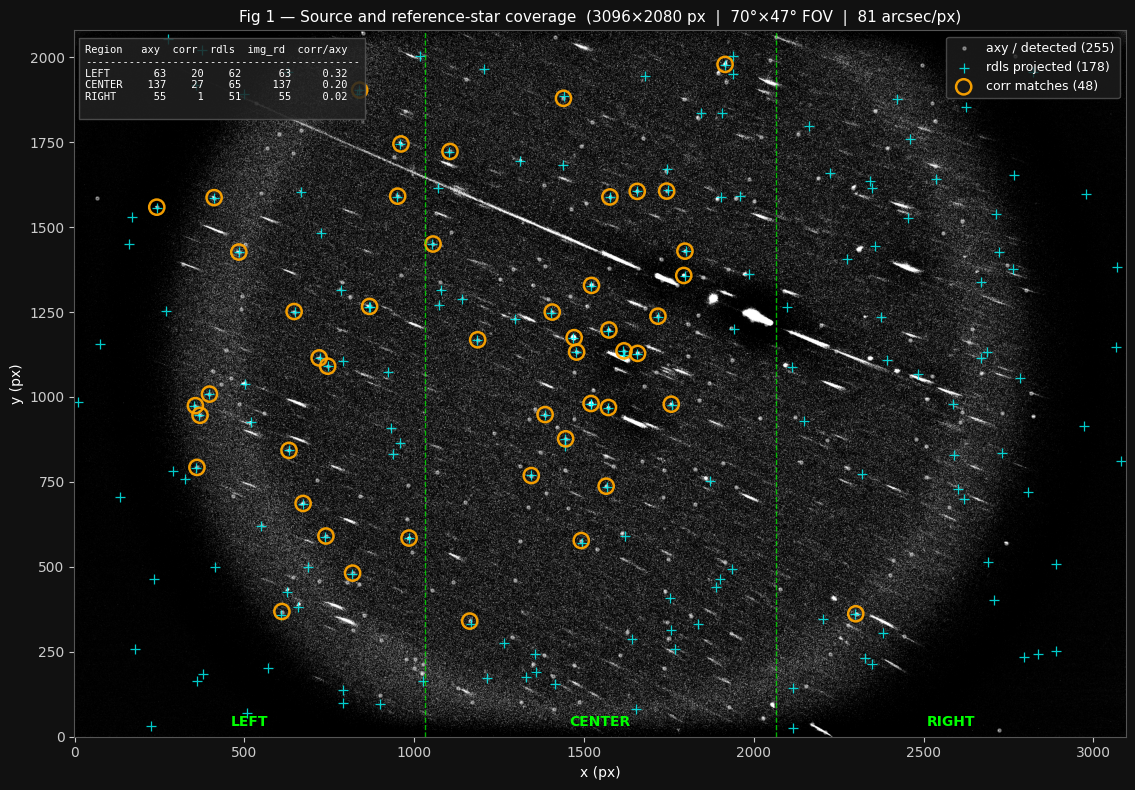

Saved wcs09_01_source_coverage.png


In [2]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(disp, origin='lower', cmap='gray', vmin=_vlo, vmax=_vhi, aspect='equal')

if src_x is not None:
    ax.scatter(src_x, src_y, s=5, c='white', alpha=0.35, label=f'axy / detected ({len(src_x)})')
if len(rdls_px_f) > 0:
    ax.scatter(rdls_px_f, rdls_py_f, s=55, marker='+', c='cyan',
               linewidths=0.9, alpha=0.8, label=f'rdls projected ({len(rdls_px_f)})')
if corr_fx is not None:
    ax.scatter(corr_fx, corr_fy, s=120, facecolors='none', edgecolors='orange',
               linewidths=1.8, alpha=0.95, label=f'corr matches ({len(corr_fx)})')

for xv in [w/3, 2*w/3]:
    ax.axvline(xv, color='lime', lw=1.0, linestyle='--', alpha=0.7)
for xv, lbl in [(w/6,'LEFT'), (w/2,'CENTER'), (5*w/6,'RIGHT')]:
    ax.text(xv, h*0.01, lbl, color='lime', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_xlim(-0.5, w-0.5); ax.set_ylim(-0.5, h-0.5)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.set_title(f'Fig 1 — Source and reference-star coverage  '
             f'({w}×{h} px  |  {fov_w:.0f}°×{fov_h:.0f}° FOV  |  '
             f'{plate_scale:.0f} arcsec/px)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)

# Source count table inset
_tdata = [
    ('LEFT',   int((src_x<w/3).sum()), int((corr_fx<w/3).sum()) if corr_fx is not None else 0,
               int((rdls_px_f<w/3).sum()), int((imgrd_x<w/3).sum()) if imgrd_x is not None else 0),
    ('CENTER', int(((src_x>=w/3)&(src_x<2*w/3)).sum()),
               int(((corr_fx>=w/3)&(corr_fx<2*w/3)).sum()) if corr_fx is not None else 0,
               int(((rdls_px_f>=w/3)&(rdls_px_f<2*w/3)).sum()),
               int(((imgrd_x>=w/3)&(imgrd_x<2*w/3)).sum()) if imgrd_x is not None else 0),
    ('RIGHT',  int((src_x>=2*w/3).sum()),
               int((corr_fx>=2*w/3).sum()) if corr_fx is not None else 0,
               int((rdls_px_f>=2*w/3).sum()),
               int((imgrd_x>=2*w/3).sum()) if imgrd_x is not None else 0),
]
_tbl_text = 'Region   axy  corr  rdls  img_rd  corr/axy\n'
_tbl_text += '-' * 44 + '\n'
for rname, na, nc, nr, ni in _tdata:
    ca = f'{nc/na:.2f}' if na > 0 else '---'
    _tbl_text += f'{rname:8s}  {na:>3}   {nc:>3}   {nr:>3}     {ni:>3}     {ca}\n'
ax.text(0.01, 0.98, _tbl_text, transform=ax.transAxes, va='top', ha='left',
        fontsize=7.5, fontfamily='monospace', color='white',
        bbox=dict(facecolor='#222', edgecolor='#555', alpha=0.85, pad=4))

plt.tight_layout()
plt.savefig(SAVE_DIR / 'wcs09_01_source_coverage.png', bbox_inches='tight')
plt.show()
print('Saved wcs09_01_source_coverage.png')

**Figure 1:** The right side of the detector has detected sources (white) and projected reference stars (cyan), but almost no `corr` matches (orange — only 1 in the right third). `corr.fits` is an internal astrometry.net correspondence subset used for the solve; its spatial bias does not mean the right side lacks useful data.  It does mean `corr.fits` cannot be used as a full-detector residual map.

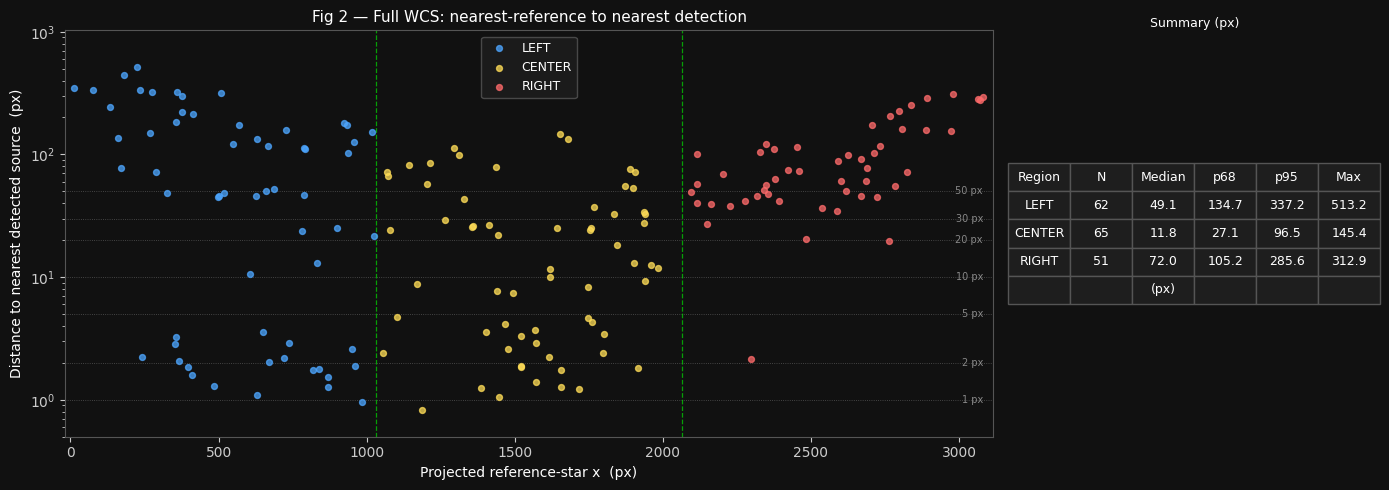

Saved wcs09_02_nearest_centroid_vs_x.png


In [3]:
if len(dists_full) == 0 or len(rdls_px_f) == 0:
    print('Nearest-centroid data not available — check rdls_tbl and src_x.')
else:
    # Region mask for projected reference stars
    _col_vals = np.where(rdls_px_f < w/3, 0,
                np.where(rdls_px_f < 2*w/3, 1, 2))
    _region_colors = ['#4da6ff', '#ffdd57', '#ff6b6b']  # left, center, right
    _region_labels = ['LEFT', 'CENTER', 'RIGHT']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             gridspec_kw={'width_ratios': [2.5, 1]})

    ax = axes[0]
    for ri, (col, lbl) in enumerate(zip(_region_colors, _region_labels)):
        mask = _col_vals == ri
        ax.scatter(rdls_px_f[mask], dists_full[mask], c=col, s=18,
                   alpha=0.75, label=lbl, zorder=3)
    for thr in [1, 2, 5, 10, 20, 30, 50]:
        ax.axhline(thr, color='#555', lw=0.6, linestyle=':')
        ax.text(w*0.995, thr, f'{thr} px', color='#888', fontsize=7,
                va='center', ha='right')
    for xv in [w/3, 2*w/3]:
        ax.axvline(xv, color='lime', lw=0.9, linestyle='--', alpha=0.6)
    ax.set_xlabel('Projected reference-star x  (px)')
    ax.set_ylabel('Distance to nearest detected source  (px)')
    ax.set_title('Fig 2 — Full WCS: nearest-reference to nearest detection', fontsize=11)
    ax.set_xlim(-20, w+20)
    ax.set_yscale('log')
    ax.set_ylim(0.5, dists_full.max() * 2)
    ax.legend(fontsize=9)

    # Stats table
    ax2 = axes[1]
    ax2.axis('off')
    _rows = [['Region', 'N', 'Median', 'p68', 'p95', 'Max']]
    for ri, lbl in enumerate(_region_labels):
        mask = _col_vals == ri
        d = dists_full[mask]
        if len(d) == 0:
            _rows.append([lbl, '0', '—', '—', '—', '—'])
        else:
            _rows.append([lbl, str(len(d)),
                          f'{np.median(d):.1f}',
                          f'{np.percentile(d,68):.1f}',
                          f'{np.percentile(d,95):.1f}',
                          f'{d.max():.1f}'])
    _rows.append(['', '', '(px)', '', '', ''])

    _tbl = ax2.table(cellText=_rows[1:], colLabels=_rows[0],
                     loc='center', cellLoc='center')
    _tbl.auto_set_font_size(False)
    _tbl.set_fontsize(9)
    _tbl.scale(1.0, 1.6)
    for (row, col), cell in _tbl.get_celld().items():
        cell.set_facecolor('#1e1e1e')
        cell.set_edgecolor('#555')
        cell.set_text_props(color='white')
    ax2.set_title('Summary (px)', fontsize=9, pad=2)

    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'wcs09_02_nearest_centroid_vs_x.png', bbox_inches='tight')
    plt.show()
    print('Saved wcs09_02_nearest_centroid_vs_x.png')

**Figure 2:** Using the full-frame WCS to project catalog reference stars (rdls) into detector coordinates, the distances to the nearest detected source are strongly field-dependent.  The centre is well-aligned (median ≈ 12 px ≈ 16'), while the left (median ≈ 49 px ≈ 1.1°) and right (median ≈ 72 px ≈ 1.6°) are substantially worse.  A WCS with uniform residuals would show no trend with x position. Note: log y-axis.

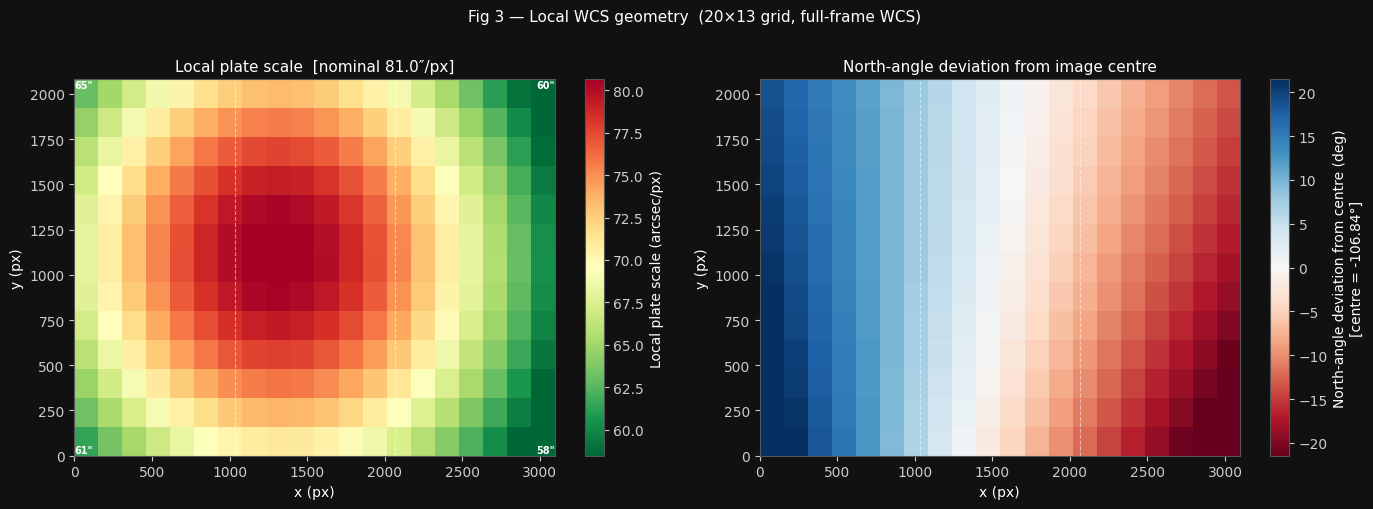

Saved wcs09_03_local_geometry.png
  Scale range across detector: 56.3 – 81.0 arcsec/px
  North-angle deviation range: -24.75 – 24.29 deg


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Local plate scale
ax = axes[0]
_scale_vmin = np.nanpercentile(scale_map, 2)
_scale_vmax = np.nanpercentile(scale_map, 98)
im1 = ax.imshow(scale_map, origin='lower', extent=[0, w, 0, h],
                cmap='RdYlGn_r', aspect='auto',
                vmin=_scale_vmin, vmax=_scale_vmax)
cb1 = plt.colorbar(im1, ax=ax, label='Local plate scale (arcsec/px)')
for xv in [w/3, 2*w/3]:
    ax.axvline(xv, color='white', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.set_title(f'Local plate scale  [nominal {plate_scale:.1f}″/px]')
# Annotate corners with scale value
for xi, yi, xp, yp in [(2,2,'left','bottom'),(w-2,2,'right','bottom'),
                         (2,h-2,'left','top'),(w-2,h-2,'right','top')]:
    _gxi = int(xi / w * (_gnx-1)); _gyi = int(yi / h * (_gny-1))
    _sv = scale_map[_gyi, _gxi]
    ax.text(xi, yi, f'{_sv:.0f}"', color='white', fontsize=7,
            ha=xp, va=yp, fontweight='bold')

# Panel 2: North-angle deviation from centre
ax = axes[1]
_nd_lim = max(abs(np.nanpercentile(north_delta_map, [2, 98])).max(), 0.5)
im2 = ax.imshow(north_delta_map, origin='lower', extent=[0, w, 0, h],
                cmap='RdBu', aspect='auto', vmin=-_nd_lim, vmax=_nd_lim)
cb2 = plt.colorbar(im2, ax=ax,
                   label=f'North-angle deviation from centre (deg)\n'
                         f'[centre = {north_centre:.2f}°]')
for xv in [w/3, 2*w/3]:
    ax.axvline(xv, color='white', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.set_title('North-angle deviation from image centre')

fig.suptitle(f'Fig 3 — Local WCS geometry  ({_gnx}×{_gny} grid, full-frame WCS)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'wcs09_03_local_geometry.png', bbox_inches='tight')
plt.show()
print('Saved wcs09_03_local_geometry.png')
print(f'  Scale range across detector: '
      f'{np.nanmin(scale_map):.1f} – {np.nanmax(scale_map):.1f} arcsec/px')
print(f'  North-angle deviation range: '
      f'{np.nanmin(north_delta_map):.2f} – {np.nanmax(north_delta_map):.2f} deg')

**Figure 3:** The WCS is strongly field-dependent over this ≈70° × 47° field. The local plate scale varies substantially from edge to edge, and the direction of celestial north rotates by multiple degrees across the detector. This is *expected physics* for a widefield lens — it does not by itself mean the WCS is wrong.  It does confirm that a single global rotation/scale is completely inadequate and that per-trace WCS Jacobian corrections are mandatory.  The diagnostic question is whether the WCS *model* captures this variation correctly.

Region                   N   N_corr            RA           Dec    North°    dNorth°
-------------------------------------------------------------------------------------
FULL                   255       48     113.40377      30.39182  -106.838     +0.000
LEFT_HALF              125        0     113.42458      30.41752  -107.522     -0.683
RIGHT_HALF             130       51     113.35289      30.41250  -107.971     -1.133
CENTER_THIRD           137       72     113.41674      30.42693  -106.987     -0.149
LEFT_PLUS_CENTER       200       50     113.37989      30.39954  -107.126     -0.288
CENTER_PLUS_RIGHT      192       49     113.43005      30.44579  -107.259     -0.421


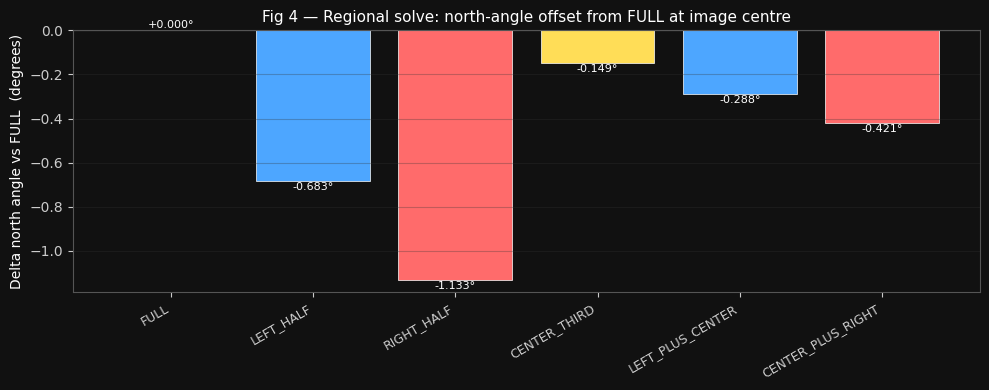

Saved wcs09_04_regional_solve_summary.png
Saved wcs09_summary_metrics.csv


In [5]:
_plot_order = ['FULL','LEFT_HALF','RIGHT_HALF','CENTER_THIRD',
               'LEFT_PLUS_CENTER','CENTER_PLUS_RIGHT']

_ref_north  = _north_angle(full_wcs, cx, cy)
_rows_fig4  = []

for name in _plot_order:
    res = regional_results.get(name)
    mask = REGION_MASKS.get(name, np.ones(len(src_x), bool))
    n_src = int(mask.sum())
    if res is None:
        _rows_fig4.append({'region': name, 'n_src': n_src, 'status': 'FAILED/SKIP',
                           'n_corr': 0, 'ra': np.nan, 'dec': np.nan,
                           'north': np.nan, 'dnorth': np.nan})
        continue
    n_corr = len(res.corr_table) if res.corr_table is not None else 0
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            _rwcs = WCS(res.header)
        ra, dec = _rwcs.pixel_to_world_values(cx, cy)
        north   = _north_angle(_rwcs, cx, cy)
        dnorth  = north - _ref_north
    except Exception:
        ra = dec = north = dnorth = np.nan
    _rows_fig4.append({'region': name, 'n_src': n_src, 'status': 'OK',
                       'n_corr': n_corr, 'ra': float(ra), 'dec': float(dec),
                       'north': float(north), 'dnorth': float(dnorth)})

# Save solve-summary CSV
_csv_buf = _io.StringIO()
_wr = csv.DictWriter(_csv_buf, fieldnames=list(_rows_fig4[0].keys()))
_wr.writeheader(); _wr.writerows(_rows_fig4)
(SAVE_DIR / 'wcs09_summary_metrics.csv').write_text(_csv_buf.getvalue(), encoding='utf-8')

# Print table
print(f"{'Region':20s}  {'N':>4}  {'N_corr':>7}  {'RA':>12}  {'Dec':>12}  "      f"{'North°':>8}  {'dNorth°':>9}")
print('-' * 85)
for r in _rows_fig4:
    if r['status'] != 'OK':
        print(f"{r['region']:20s}  {r['n_src']:>4}  --- {r['status']}")
    else:
        print(f"{r['region']:20s}  {r['n_src']:>4}  {r['n_corr']:>7}  "              f"{r['ra']:>12.5f}  {r['dec']:>12.5f}  "              f"{r['north']:>8.3f}  {r['dnorth']:>+9.3f}")

# Bar chart of delta north angle
_ok = [r for r in _rows_fig4 if r['status']=='OK' and not np.isnan(r['dnorth'])]
_names = [r['region'] for r in _ok]
_dn    = [r['dnorth'] for r in _ok]
_cols  = ['#888' if n=='FULL' else '#4da6ff' if 'LEFT' in n
          else '#ff6b6b' if 'RIGHT' in n else '#ffdd57' for n in _names]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(_names)), _dn, color=_cols, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='white', lw=0.8, alpha=0.6)
ax.set_xticks(range(len(_names)))
ax.set_xticklabels(_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Delta north angle vs FULL  (degrees)')
ax.set_title('Fig 4 — Regional solve: north-angle offset from FULL at image centre',
             fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Label bars
for i, (bar, v) in enumerate(zip(bars, _dn)):
    ax.text(bar.get_x() + bar.get_width()/2, v + np.sign(v)*0.005,
            f'{v:+.3f}°', ha='center', va='bottom' if v>=0 else 'top',
            fontsize=8, color='white')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'wcs09_04_regional_solve_summary.png', bbox_inches='tight')
plt.show()
print('Saved wcs09_04_regional_solve_summary.png')
print('Saved wcs09_summary_metrics.csv')

**Figure 4:** Different spatial subsets of the same detected sources return different WCS solutions at the image centre.  North-angle offsets range from ≈ −0.1° to ≈ −1.1° relative to the full-frame solve, and the RA/Dec centre can shift by several arcminutes.  An astrometrically stable system would return the same local WCS regardless of which sources are used to constrain it; the variation here indicates the global SIP=2 model is under-constrained for this field size.

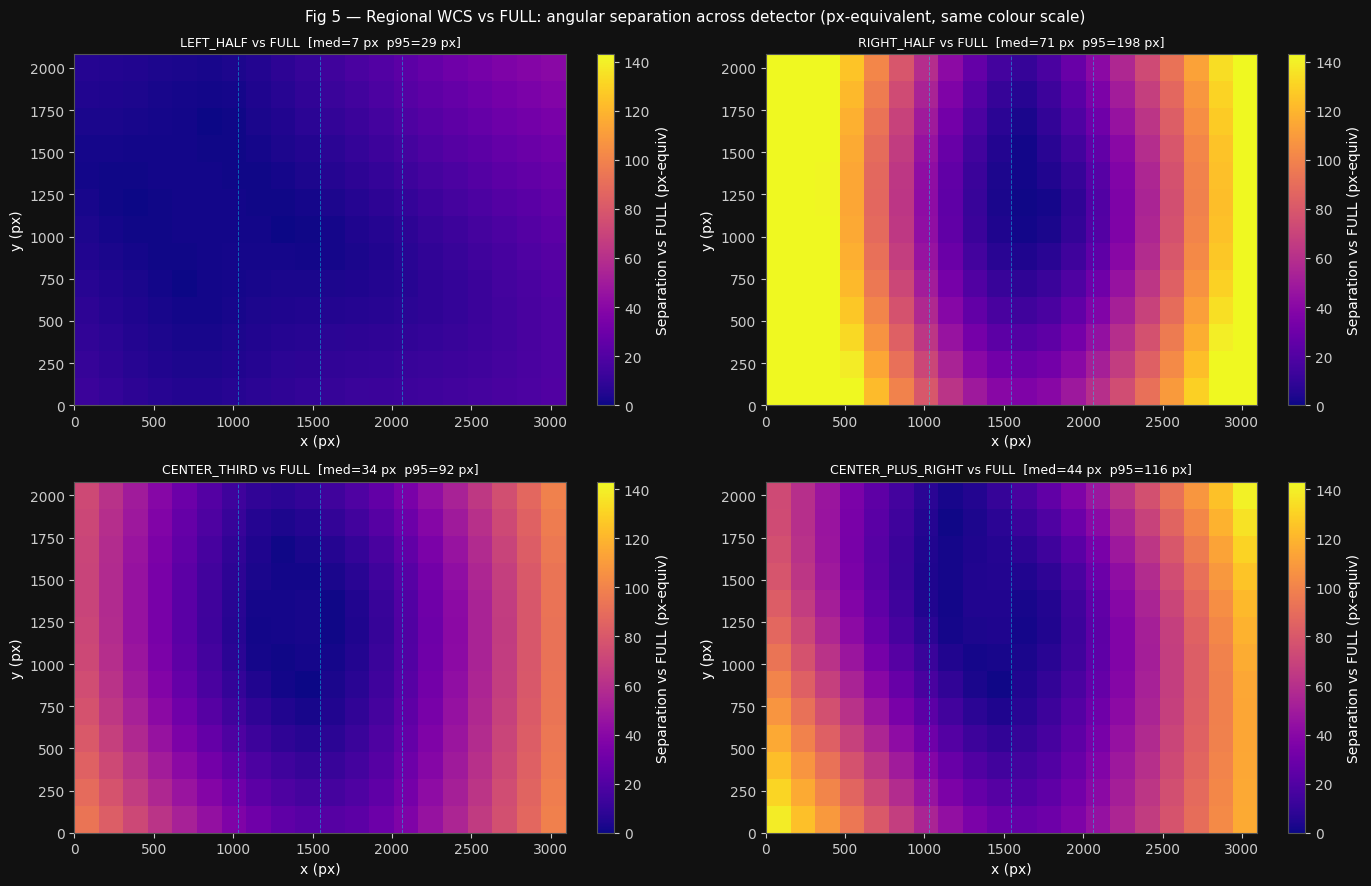

Saved wcs09_05_regional_vs_full_maps.png


In [6]:
_map_regions = ['LEFT_HALF','RIGHT_HALF','CENTER_THIRD','CENTER_PLUS_RIGHT']
_available   = [r for r in _map_regions if regional_results.get(r) is not None]

if not _available:
    print('No regional solve results available for difference maps.')
else:
    sep_maps = {}
    for name in _available:
        res = regional_results[name]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            _rwcs = WCS(res.header)
            _rra, _rdec = _rwcs.pixel_to_world_values(gx_flat, gy_flat)
        _rsky = SkyCoord(ra=_rra*u.deg, dec=_rdec*u.deg)
        sep_maps[name] = (full_sky_g.separation(_rsky).arcsec / plate_scale
                          ).reshape(_gny, _gnx)

    _vmax = np.nanpercentile(
        np.concatenate([m.ravel() for m in sep_maps.values()]), 95)

    ncols = 2
    nrows = (len(_available) + 1) // 2
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(7*ncols, 4.5*nrows), squeeze=False)

    for idx, name in enumerate(sorted(_available,
                                      key=lambda n: list(REGION_MASKS).index(n))):
        ax = axes[idx//ncols][idx%ncols]
        m  = sep_maps[name]
        im = ax.imshow(m, origin='lower', extent=[0,w,0,h],
                       cmap='plasma', aspect='auto', vmin=0, vmax=_vmax)
        plt.colorbar(im, ax=ax, label='Separation vs FULL (px-equiv)')
        for xv in [w/3, w/2, 2*w/3]:
            ax.axvline(xv, color='cyan', lw=0.7, linestyle='--', alpha=0.4)
        _med = np.nanmedian(m); _p95 = np.nanpercentile(m, 95)
        ax.set_title(f'{name} vs FULL  [med={_med:.0f} px  p95={_p95:.0f} px]',
                     fontsize=9)
        ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

    for idx in range(len(_available), nrows*ncols):
        axes[idx//ncols][idx%ncols].set_visible(False)

    fig.suptitle('Fig 5 — Regional WCS vs FULL: angular separation across detector '
                 '(px-equivalent, same colour scale)', fontsize=11)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'wcs09_05_regional_vs_full_maps.png', bbox_inches='tight')
    plt.show()
    print('Saved wcs09_05_regional_vs_full_maps.png')

**Figure 5:** Each regional WCS agrees with the full-frame WCS near the region that constrained it, but diverges strongly elsewhere — sometimes by hundreds of pixel-equivalents.  This is the spatial manifestation of the solve instability: there is no single TAN-SIP(2) model that fits all parts of the detector consistently.

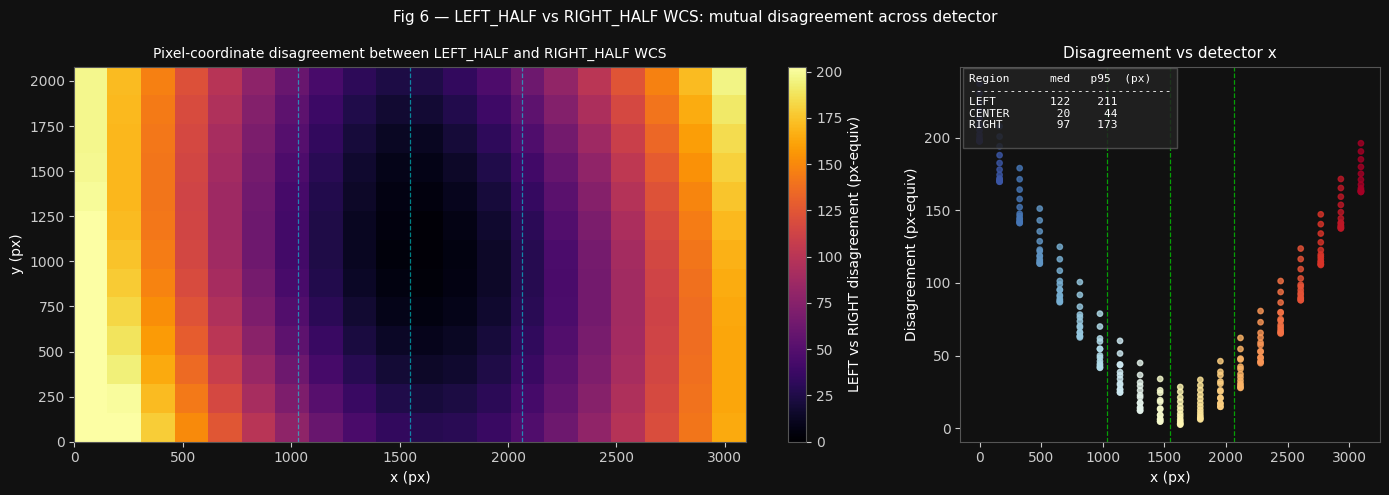

Saved wcs09_06_left_vs_right_map.png


In [7]:
left_res  = regional_results.get('LEFT_HALF')
right_res = regional_results.get('RIGHT_HALF')

if left_res is None or right_res is None:
    print('LEFT_HALF or RIGHT_HALF solve not available — rerun wcs_08.')
else:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _lwcs = WCS(left_res.header)
        _rwcs = WCS(right_res.header)
        _lra, _ldec = _lwcs.pixel_to_world_values(gx_flat, gy_flat)
        _rra, _rdec = _rwcs.pixel_to_world_values(gx_flat, gy_flat)

    _lsky = SkyCoord(ra=_lra*u.deg, dec=_ldec*u.deg)
    _rsky = SkyCoord(ra=_rra*u.deg, dec=_rdec*u.deg)
    _lr_sep = (_lsky.separation(_rsky).arcsec / plate_scale)
    _lr_map = _lr_sep.reshape(_gny, _gnx)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             gridspec_kw={'width_ratios': [2, 1]})

    ax = axes[0]
    _vmax6 = np.nanpercentile(_lr_sep, 97)
    im = ax.imshow(_lr_map, origin='lower', extent=[0,w,0,h],
                   cmap='inferno', aspect='auto', vmin=0, vmax=_vmax6)
    plt.colorbar(im, ax=ax, label='LEFT vs RIGHT disagreement (px-equiv)')
    for xv in [w/3, w/2, 2*w/3]:
        ax.axvline(xv, color='cyan', lw=0.9, linestyle='--', alpha=0.5)
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    ax.set_title('Pixel-coordinate disagreement between LEFT_HALF and RIGHT_HALF WCS',
                 fontsize=10)

    # Scatter version
    ax2 = axes[1]
    ax2.scatter(gx_flat, _lr_sep, c=gx_flat/w, cmap='RdYlBu_r', s=15, alpha=0.8,
                vmin=0, vmax=1)
    for xv in [w/3, w/2, 2*w/3]:
        ax2.axvline(xv, color='lime', lw=0.9, linestyle='--', alpha=0.6)
    ax2.set_xlabel('x (px)')
    ax2.set_ylabel('Disagreement (px-equiv)')
    ax2.set_title('Disagreement vs detector x')

    # Stats annotation
    _stats_txt = 'Region      med   p95  (px)\n'
    _stats_txt += '-' * 30 + '\n'
    for rname, x0, x1 in [('LEFT', 0, w/3), ('CENTER', w/3, 2*w/3), ('RIGHT', 2*w/3, w)]:
        mask = (gx_flat >= x0) & (gx_flat < x1)
        d = _lr_sep[mask]
        _stats_txt += f'{rname:8s}  {np.median(d):>5.0f}  {np.percentile(d,95):>5.0f}\n'
    ax2.text(0.02, 0.98, _stats_txt, transform=ax2.transAxes, va='top', ha='left',
             fontsize=8, fontfamily='monospace', color='white',
             bbox=dict(facecolor='#222', edgecolor='#555', alpha=0.85, pad=4))

    fig.suptitle('Fig 6 — LEFT_HALF vs RIGHT_HALF WCS: mutual disagreement across detector',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'wcs09_06_left_vs_right_map.png', bbox_inches='tight')
    plt.show()
    print('Saved wcs09_06_left_vs_right_map.png')

**Figure 6:** This is the most decisive diagnostic.  Two successful plate-solves — one using only left-half sources, one using only right-half sources — disagree by ≈ 20 px at the detector centre and by 100–200 px-equivalent at the edges.  A valid distortion model should be consistent regardless of which sources constrain it. The strong mutual disagreement confirms that SIP=2 cannot simultaneously fit both halves of this field, and that no single current WCS can be trusted as a precision correction across the full detector.

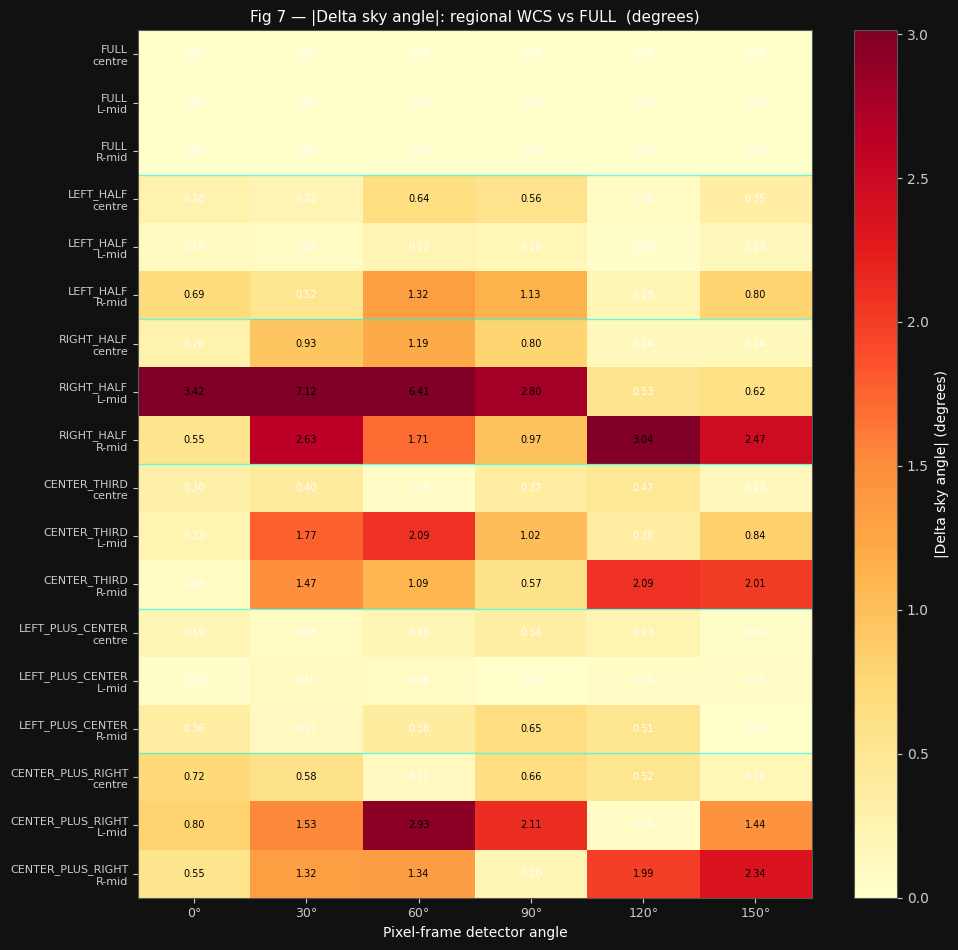

Saved wcs09_07_angle_impact.png
Saved wcs09_angle_impact_summary.csv

Worst-case |delta sky angle| per region/position combination:
  FULL/centre                   : max=0.000 deg  mean=0.000 deg
  FULL/L-mid                    : max=0.000 deg  mean=0.000 deg
  FULL/R-mid                    : max=0.000 deg  mean=0.000 deg
  LEFT_HALF/centre              : max=0.637 deg  mean=0.355 deg
  LEFT_HALF/L-mid               : max=0.218 deg  mean=0.122 deg
  LEFT_HALF/R-mid               : max=1.321 deg  mean=0.775 deg
  RIGHT_HALF/centre             : max=1.193 deg  mean=0.578 deg
  RIGHT_HALF/L-mid              : max=7.122 deg  mean=3.483 deg
  RIGHT_HALF/R-mid              : max=3.036 deg  mean=1.892 deg
  CENTER_THIRD/centre           : max=0.472 deg  mean=0.291 deg
  CENTER_THIRD/L-mid            : max=2.088 deg  mean=1.054 deg
  CENTER_THIRD/R-mid            : max=2.093 deg  mean=1.221 deg
  LEFT_PLUS_CENTER/centre       : max=0.339 deg  mean=0.178 deg
  LEFT_PLUS_CENTER/L-mid        : ma

In [8]:
_theta_pix_vals = [0, 30, 60, 90, 120, 150]
_test_positions = [
    ('centre', cx,       cy),
    ('L-mid',  w*0.17,   cy),
    ('R-mid',  w*0.83,   cy),
]
_angle_regions = ['FULL','LEFT_HALF','RIGHT_HALF','CENTER_THIRD',
                  'LEFT_PLUS_CENTER','CENTER_PLUS_RIGHT']
_angle_regions = [r for r in _angle_regions if regional_results.get(r) is not None]

# Pre-compute FULL reference angles
_ref_sky = {}
for pos_name, tx, ty in _test_positions:
    for th in _theta_pix_vals:
        _ref_sky[(pos_name, th)] = _pix_to_sky_angle(full_wcs, tx, ty, th)

# Build matrix: rows=(region,pos), cols=theta_pix
_row_labels, _data_matrix, _csv_rows = [], [], []
for name in _angle_regions:
    res = regional_results[name]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _rwcs = WCS(res.header)
    for pos_name, tx, ty in _test_positions:
        _row = []
        for th in _theta_pix_vals:
            sky_reg  = _pix_to_sky_angle(_rwcs, tx, ty, th)
            sky_full = _ref_sky[(pos_name, th)]
            delta = sky_reg - sky_full
            while delta >  90: delta -= 180
            while delta <= -90: delta += 180
            _row.append(abs(delta))
            _csv_rows.append({'region': name, 'position': pos_name,
                               'theta_pix': th, 'abs_delta_deg': round(abs(delta), 4)})
        _data_matrix.append(_row)
        _row_labels.append(f'{name}\n{pos_name}')

_mat = np.array(_data_matrix)

# Save angle impact CSV
_csv_buf2 = _io.StringIO()
_wr2 = csv.DictWriter(_csv_buf2,
                       fieldnames=['region','position','theta_pix','abs_delta_deg'])
_wr2.writeheader(); _wr2.writerows(_csv_rows)
(SAVE_DIR / 'wcs09_angle_impact_summary.csv').write_text(
    _csv_buf2.getvalue(), encoding='utf-8')

# Heatmap
fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(_row_labels) + 1.5)))
im = ax.imshow(_mat, cmap='YlOrRd', aspect='auto', vmin=0,
               vmax=max(np.nanpercentile(_mat, 97), 0.1))
plt.colorbar(im, ax=ax, label='|Delta sky angle| (degrees)')

ax.set_xticks(range(len(_theta_pix_vals)))
ax.set_xticklabels([f'{t}°' for t in _theta_pix_vals], fontsize=9)
ax.set_yticks(range(len(_row_labels)))
ax.set_yticklabels(_row_labels, fontsize=8)
ax.set_xlabel('Pixel-frame detector angle')
ax.set_title('Fig 7 — |Delta sky angle|: regional WCS vs FULL  (degrees)', fontsize=11)

# Annotate cells
for i in range(_mat.shape[0]):
    for j in range(_mat.shape[1]):
        v = _mat[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=7, color='black' if v > np.nanpercentile(_mat, 60) else 'white')

# Separator lines between regions
n_pos = len(_test_positions)
for k in range(len(_angle_regions)-1):
    y_sep = (k+1)*n_pos - 0.5
    ax.axhline(y_sep, color='cyan', lw=1.0, alpha=0.6)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'wcs09_07_angle_impact.png', bbox_inches='tight')
plt.show()
print('Saved wcs09_07_angle_impact.png')
print('Saved wcs09_angle_impact_summary.csv')
print()
print('Worst-case |delta sky angle| per region/position combination:')
for i, lbl in enumerate(_row_labels):
    print(f'  {lbl.replace(chr(10),"/"):30s}: max={_mat[i].max():.3f} deg  '          f'mean={_mat[i].mean():.3f} deg')

**Figure 7:** WCS choice translates directly into recovered sky-angle error. Even at the image centre, different regional plate-solves change the inferred sky angle by up to ≈1°, depending on which detector angle is measured.  Off-centre positions reach several degrees in the worst cases.  The target precision for spectral angle extraction is typically 0.1° or better; the current WCS systematic alone already exceeds the entire precision budget.

In [9]:
print('Output files in', SAVE_DIR)
for f in sorted(SAVE_DIR.iterdir()):
    size = f.stat().st_size
    print(f'  {f.name:45s}  {size:>8,} bytes')

Output files in C:\Users\bassd\Research\Spectra Angle\spectrangle\out\wcs_diagnostics\final_summary
  wcs09_01_source_coverage.png                   2,023,337 bytes
  wcs09_02_nearest_centroid_vs_x.png              114,330 bytes
  wcs09_03_local_geometry.png                      96,659 bytes
  wcs09_04_regional_solve_summary.png              57,506 bytes
  wcs09_05_regional_vs_full_maps.png              155,104 bytes
  wcs09_06_left_vs_right_map.png                  136,673 bytes
  wcs09_07_angle_impact.png                       143,529 bytes
  wcs09_angle_impact_summary.csv                    3,305 bytes
  wcs09_summary_metrics.csv                           640 bytes


## Final Summary

### What succeeds
- Nova.astrometry.net successfully identifies the field (RA ≈ 120.6°, Dec ≈ 29.8°).
- A CTYPE1 = RA---TAN-SIP (order 2) WCS is returned and passes internal roundtrip checks.
- All regional source-list subsets with ≥ 15 sources produce independent successful solves.
- The image centre is tolerably well-aligned: median nearest-reference distance ≈ 12 px (≈ 0.27°).

### What does not hold for precision angle extraction

| Diagnostic | Result | Implication |
|---|---|---|
| `corr.fits` coverage | 48 matches, strongly biased to left/centre; only 1 on right | Cannot use as full-detector residual map |
| Nearest-centroid vs x | LEFT median 49 px, RIGHT median 72 px vs centre 12 px | WCS alignment degrades strongly at edges |
| Regional solve consistency | North-angle spread ≈ 1.1° across regional solves | Global SIP=2 under-constrained for this FOV |
| LEFT vs RIGHT disagreement | Centre ≈ 20 px, edges 100–200 px | Two valid sub-solves are mutually incompatible |
| Angle impact | Up to ≈ 1° at centre, several degrees off-centre | WCS systematic alone exceeds precision budget |

### Root cause
The field is ≈ 70° × 47° — this is an extreme wide-field regime.  A TAN projection with SIP order 2 has only ≈ 10 distortion coefficients, which are insufficient to describe the scale and orientation variation across this FOV.  The plate-solver finds a globally plausible solution but the residual distortion is degree-scale and spatially coherent.

### Practical recommendations

1. **Restrict to a validated central subregion** for any near-term precision    angle measurement.  The centre (roughly the central third) appears stable to    ≲ 20 px matching and ≲ 0.2° angle impact.

2. **Use a smaller-FOV image** (longer focal length, or crop + re-solve).     At < 20° FOV, SIP=2 would be adequate for sub-pixel astrometry.

3. **Fit a physical camera distortion model** (e.g., barrel/pincushion +    field rotation polynomial) rather than relying on astrometry.net's generic    SIP fit.  This requires a denser reference-star grid or a lab calibration target.

4. **Do not use regional solves as final corrections.**  They are useful diagnostics    but each extrapolates poorly outside its constraining region.

5. **Report WCS systematic error as an uncertainty floor.**  At the image centre,    the WCS-related angle uncertainty is ≈ 0.5–1°.  This should be propagated into    all reported grating/trace orientation measurements derived from this dataset.